In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from lpips import LPIPS
from pytorch_msssim import SSIM

import os
import sys
sys.path.append(os.path.abspath('..'))
os.chdir('..')
from inference import build_espcn, build_restormer

import time

In [2]:
class TrainImageDataset(Dataset):
    def __init__(self, image_dir) -> None:
        self.image_dir = Path(image_dir)
        self.GT_PATH = self.image_dir / 'GT'  # Assuming GT images are in a subdirectory named 'GT'
        self.NoisyLR_PATH = self.image_dir / 'NoisyLR'  # Assuming NoisyLR images are in a subdirectory named 'NoisyLR'
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))  # Assuming images are in .npy format
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))  # Assuming images are in .npy format
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

    def __len__(self) -> int:
        return len(self.GT_image_paths)

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        GT_image = np.load(self.GT_image_paths[idx])  # Load the GT image
        NoisyLR_image = np.load(self.NoisyLR_image_paths[idx])
        return torch.from_numpy(NoisyLR_image), torch.from_numpy(GT_image)  # Return both images

    def refresh(self) -> None:
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

In [3]:
original_dataset = TrainImageDataset("data/train/train")

ESPCN model loaded successfully.
Restormer model loaded successfully.
cuda:0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


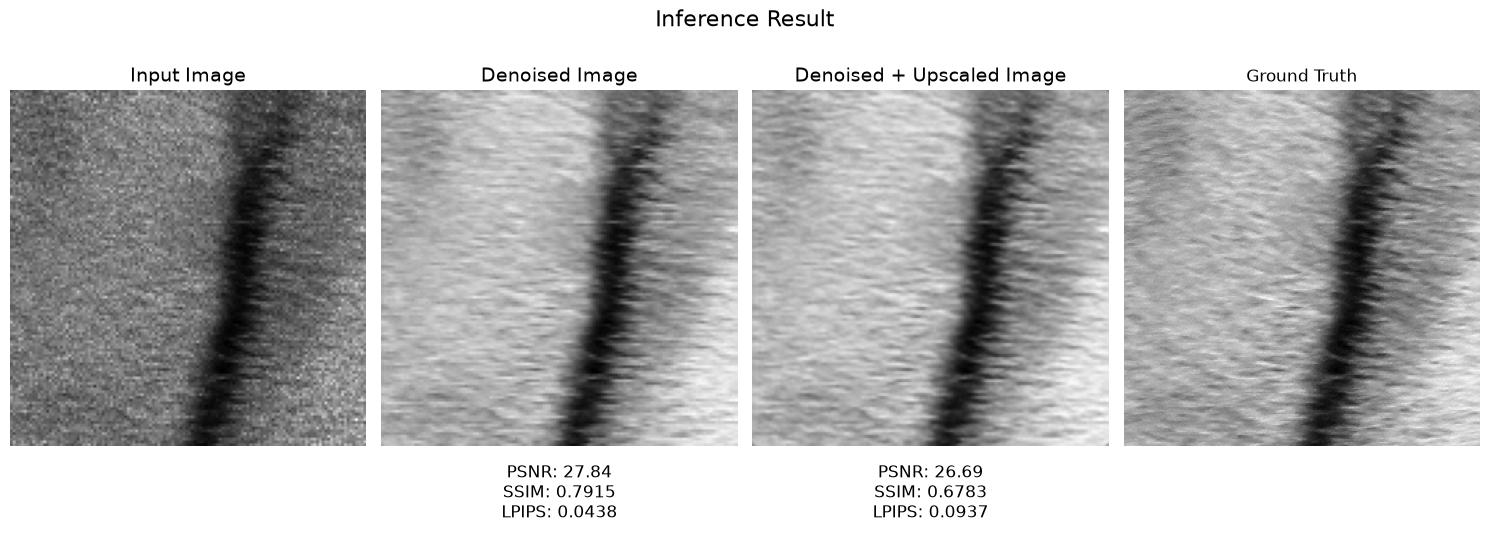

Total time taken: 0.045073747634887695 seconds


In [5]:
noisy_tensor, gt_tensor = original_dataset[69]
gt_zoomed = zoom(gt_tensor, zoom=0.5, order=3)

ESPCN_model = build_espcn()
Restormer_model = build_restormer()
DEVICE = next(ESPCN_model.parameters()).device  # Assuming both models are on the same device
print(DEVICE)

noisy_tensor = noisy_tensor.to(DEVICE).unsqueeze(0).unsqueeze(0)
gt_tensor = gt_tensor.to(DEVICE).unsqueeze(0).unsqueeze(0)
start_time = time.time()
denoised_image = Restormer_model(noisy_tensor)
upscaled_image = ESPCN_model(denoised_image)
end_time = time.time()

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle("Inference Result", fontsize=16)
axes[0].imshow(noisy_tensor.squeeze().detach().cpu().numpy(), cmap="gray")
axes[0].axis("off")
axes[0].set_title("Input Image", fontsize=14)

axes[1].imshow(denoised_image.squeeze().detach().cpu().numpy(), cmap="gray")
axes[1].axis("off")
axes[1].set_title("Denoised Image", fontsize=14)

# print metrics psnr, ssim and lpips of denoised image with input image

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from lpips import LPIPS

_LPIPS = LPIPS(net='alex')

psnr_denoise = psnr(gt_zoomed, denoised_image.squeeze().detach().cpu().numpy(), data_range=1)
ssim_denoise = ssim(gt_zoomed, denoised_image.squeeze().detach().cpu().numpy(), data_range=1)
lpips_denoise = _LPIPS(torch.from_numpy(gt_zoomed), denoised_image.squeeze().detach().cpu()).item()
axes[1].text(0.5, -0.2, f"PSNR: {psnr_denoise:.2f}\nSSIM: {ssim_denoise:.4f}\nLPIPS: {lpips_denoise:.4f}", fontsize=12, ha='center', transform=axes[1].transAxes)

axes[2].imshow(upscaled_image.squeeze().detach().cpu().numpy(), cmap="gray")
axes[2].axis("off")
axes[2].set_title("Denoised + Upscaled Image", fontsize=14)

psnr_upscale = psnr(gt_tensor.squeeze().detach().cpu().numpy(), upscaled_image.squeeze().detach().cpu().numpy(), data_range=1)
ssim_upscale = ssim(gt_tensor.squeeze().detach().cpu().numpy(), upscaled_image.squeeze().detach().cpu().numpy(), data_range=1)
lpips_upscale = _LPIPS(gt_tensor.squeeze().cpu(), upscaled_image.squeeze().detach().cpu()).item()
axes[2].text(0.5, -0.2, f"PSNR: {psnr_upscale:.2f}\nSSIM: {ssim_upscale:.4f}\nLPIPS: {lpips_upscale:.4f}", fontsize=12, ha='center', transform=axes[2].transAxes)

axes[3].imshow(gt_tensor.squeeze().detach().cpu().numpy(), cmap="grey")
axes[3].axis("off")
axes[3].set_title("Ground Truth")

plt.tight_layout()
plt.show()
print(f"Total time taken: {end_time - start_time} seconds")